# 11.1.2 规则网络与重连基线

## 学习目标与先修知识

在相同节点和边数下比较聚类、路径和重连随机性。

先修：11.1.1 度、路径与连通分量（connected component）；5.1 随机重复。

## 具体问题

一个规则接触环在局部形成不少三角形，但远处节点往往相隔多条边。替换少量边后，局部聚类（local clustering）和路径会怎样变化？一次重连结果不是普遍规律。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先检查固定节点数、边数和随机种子（random seed）；只替换边而不增加边。

In [2]:
print('30节点、每节点先接4个近邻的规则环共有', 30*4//2, '条边。')
print('重连概率0与0.4是两种结构条件，后续传播随机数另存。')

30节点、每节点先接4个近邻的规则环共有 60 条边。
重连概率0与0.4是两种结构条件，后续传播随机数另存。


## 模型假设

使用无向简单图：规则环每节点先连左右各 $k/2$ 个邻居。课程重连规则沿规则环的同一方向逐边遍历，以概率（probability） $p$ 保留出发节点并换成非自身、尚无边的另一端；不能换时维持原边。节点编号只是名字：不能先把无向边按编号大小排序，再永远保留较小编号节点。每次始终保留边数。规则是教学用有限图生成机制，不从这组图推断真实网络分布（distribution）。

## 数学解释与推导

节点 $i$ 的局部聚类（local clustering）为邻居之间实际边数除以 $d_i(d_i-1)/2$；$d_i<2$ 时本节取零。平均聚类是所有节点局部值的平均。无权平均路径按 11.1.1 定义；重连后可能断连，届时它返回 `None`，不把断连图悄悄剔除。度分布（degree distribution）是各个度值出现的频率，社区（community）通常指群内连接较密、群间较稀的节点组；两者需要明确抽样和划分定义，本课不凭有限图形声称幂律或唯一社区。重连概率是生成网络的随机性；固定一张网络以后动态事件（event）的随机性是另一层。小世界（small-world）需相对于明确的规则和随机基线比较短路径与高聚类，不能凭一次图形或双对数直线宣布。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def graph_summary(n, edges):
    """Degrees, sorted connected components and all-pairs path mean (or None)."""
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    remaining = set(range(n))
    components = []
    while remaining:
        start = min(remaining)
        queue = [start]
        remaining.remove(start)
        part = []
        for v in queue:
            part.append(v)
            for w in range(n):
                if a[v][w] and w in remaining:
                    remaining.remove(w)
                    queue.append(w)
        components.append(sorted(part))
    lengths = []
    for start in range(n):
        distance = [-1] * n
        distance[start] = 0
        queue = [start]
        for v in queue:
            for w in range(n):
                if a[v][w] and distance[w] < 0:
                    distance[w] = distance[v] + 1
                    queue.append(w)
        lengths.extend(distance[w] for w in range(start + 1, n) if distance[w] >= 0)
    mean_path = sum(lengths) / len(lengths) if len(components) == 1 and lengths else None
    return degree, components, mean_path


def ring_rewire(n, k, probability, seed):
    """Teaching ring rewiring: fixed node/edge count, one endpoint retained."""
    import random
    rng = random.Random(seed)
    # Follow one ring direction; numeric order is only the undirected edge's storage form.
    original = [(i, (i + d) % n) for i in range(n)
                for d in range(1, k // 2 + 1)]
    edges = {tuple(sorted(edge)) for edge in original}
    for i, j in original:
        if rng.random() >= probability:
            continue
        options = [w for w in range(n) if w != i and tuple(sorted((i, w))) not in edges]
        if options:
            edges.remove(tuple(sorted((i, j))))
            edges.add(tuple(sorted((i, rng.choice(options)))))
    return sorted(edges)


def mean_clustering(n, edges):
    a = adjacency(n, edges)
    local = []
    for i in range(n):
        neighbors = [j for j in range(n) if a[i][j]]
        pairs = len(neighbors) * (len(neighbors) - 1) // 2
        triangles = sum(a[j][h] for offset, j in enumerate(neighbors)
                        for h in neighbors[offset + 1:])
        local.append(triangles / pairs if pairs else 0.)
    return sum(local) / n if n else 0.

## 对照实验

对每个重连概率生成16张同规模、同边数网络，分别报告聚类、全图平均路径和断连次数；不筛选有利种子。

p= 0.0 平均聚类= 0.5 断连次数= 0 / 16
p= 0.1 平均聚类= 0.371 断连次数= 0 / 16
p= 0.4 平均聚类= 0.181 断连次数= 0 / 16
p= 1.0 平均聚类= 0.143 断连次数= 0 / 16


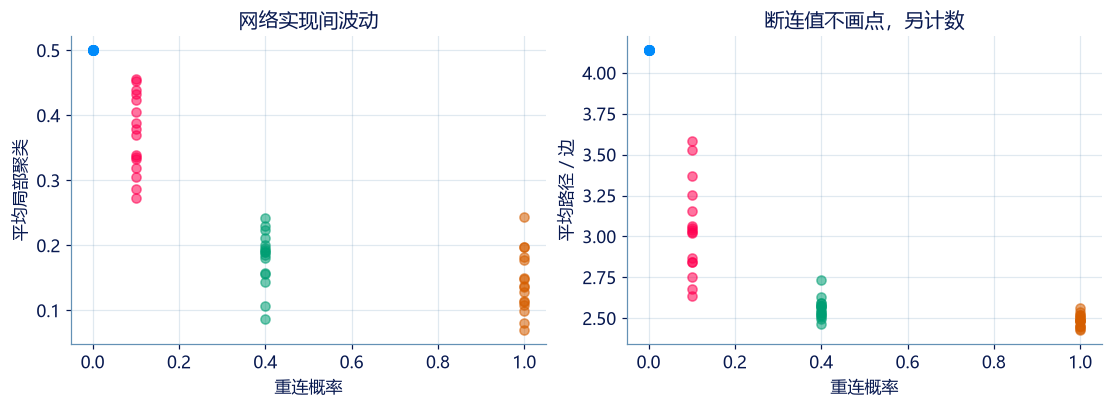

In [4]:
n, k = 30, 4
summary = {}
for probability in [0., .1, .4, 1.]:
    results = []
    for seed in range(16):
        e = ring_rewire(n, k, probability, seed)
        degree, components, distance = graph_summary(n, e)
        results.append((mean_clustering(n, e), distance, len(components), len(e)))
    summary[probability] = results
    print('p=', probability, '平均聚类=', round(np.mean([r[0] for r in results]), 3),
          '断连次数=', sum(r[1] is None for r in results), '/', len(results))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for p, rows in summary.items():
    axes[0].scatter([p]*len(rows), [r[0] for r in rows], alpha=.55)
    axes[1].scatter([p]*len(rows), [np.nan if r[1] is None else r[1] for r in rows], alpha=.55)
axes[0].set(xlabel='重连概率', ylabel='平均局部聚类', title='网络实现间波动')
axes[1].set(xlabel='重连概率', ylabel='平均路径 / 边', title='断连值不画点，另计数')
plt.show()

## 结果解释

这批有限图可能出现较短路径与仍保留的聚类，但散点体现生成实现间波动。右图缺点不表示缺失数据无关紧要：上方同时报告断连次数。边数相同不保证所有结构统计相同。 编号不参与选择保留端点；若把编号重新旋转，规则应仍在同一环位置上执行。

### 独立核对

检查每张图的边数、自环、重复与度和；三角形和路径提供局部系数的手算边界。

In [5]:
for p in [0., .1, 1.]:
    for seed in range(16):
        e = ring_rewire(n, k, p, seed)
        assert len(e) == n*k//2 and len(set(map(tuple,e))) == len(e)
        assert all(i != j for i,j in e)
        assert sum(graph_summary(n,e)[0]) == n*k
        if p == 1.:
            assert min(graph_summary(n,e)[0]) >= k//2
np.testing.assert_allclose(mean_clustering(3, [[0,1],[1,2],[0,2]]), 1.)
np.testing.assert_allclose(mean_clustering(3, [[0,1],[1,2]]), 0.)
print('边数与小图聚类边界一致。')

边数与小图聚类边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算平均局部聚类

在无向简单图上，对每个节点计算邻居之间实际相连的边数除以邻居可能边数；度不足2的节点本题局部聚类（local clustering）定义为0。返回 n 个节点的算术平均。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点总数，至少1。 | 个 |
| `edges` | `list[list[int]]` | 无向简单边。 | 条 |

**返回值**

直接返回 mean_clustering（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean_clustering` | `float` | 平均局部聚类系数。 | 1 |

**计算规则**

局部系数 C_i=已连接邻居对数 / [d_i(d_i−1)/2]，d_i<2 时取0；最后除以 n。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点总数，至少1。 | 3 | 个 |
| edges | 无向简单边。 | [[0, 1], [1, 2], [0, 2]] | 条 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 3
edges = [[0, 1], [1, 2], [0, 2]]

result = solve(n, edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean_clustering | 平均局部聚类系数。 | 1 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 1.0
```

**样例解释**

三角形每个节点的邻居彼此连接，平均聚类为1；路径图无三角。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算平均局部聚类](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-mean-local-clustering)

### 第 2 题 · 单项选择题：比较结构要匹配什么

比较规则环与重连图的路径和聚类，哪组约束让结构差异更容易解释？

- **A.** 固定节点数和边数，记录重连概率（probability）与随机种子（random seed）。
- **B.** 只固定图片宽度。
- **C.** 让重连图边数翻倍，再把差异全归因于捷径。
- **D.** 只选一次最漂亮的随机网络。

[作答：比较结构要匹配什么](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-matched-edge-budget)

### 第 3 题 · 单项选择题：度分布的证据边界

某个仅40节点的图的度频数在双对数坐标看似近直线。最稳妥的结论是什么？

- **A.** 可以立即宣布普遍幂律。
- **B.** 需与其他候选分布（distribution）、有限规模与采样（sampling）过程比较，不能凭图形判断。
- **C.** 所有重连图都必有同一幂律指数。
- **D.** 坐标变换能创造未观测（observation）到的节点。

[作答：度分布的证据边界](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-power-law-evidence)

### 第 4 题 · 多项选择题：重连实验的随机性

固定 n、k、重连概率（probability），但每次换种子。哪些判断成立？

- **A.** 边数应由声明的重连规则保持。
- **B.** 平均路径和聚类可能随具体实现波动。
- **C.** 一个实现就能给出无不确定性的普遍结论。
- **D.** 网络生成随机性与之后传播事件（event）随机性是同一随机来源。

[作答：重连实验的随机性](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-rewire-repeats)

**进一步阅读**

[NetworkX 的 Watts–Strogatz 生成器说明](https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html)强调重连不增加边数且不保证连通；本节明示自写的有限图规则。